In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import json
import scipy

# Function to parse individual entries (e.g., A0:0:7:86)
def parse_entry(entry):
    parts = entry.split(":")
    # Clean and convert values
    clean = lambda x: float(x.replace("‑", "-").replace("−", "-"))  # Replace non-standard hyphens
    if len(parts) == 4:
        key, start, length, value = parts
        return {"Encoder1": key[1:], "Encoder2": clean(start), "Voltage": clean(length), "phi": clean(value)}
    elif len(parts) == 3:
        phi, phi_dot, servo = parts
        return {"phi":phi[1:], "phi_dot": clean(phi_dot), "Servo": clean(servo)}
    else:
        return {"raw_entry": entry}  # Fallback for unexpected formats

In [42]:
def plot_line(states, title, save_fig=True, format='pdf'):
    # x_axis = [i*0.020 for i in range(len(clean_states['phi']))]
    # print(x_axis)
    # # clean_states['phi
    # # plot = clean_states['phi'].plot.line(xticks=x_axis)
    # plot = clean_states['phi'].plot.line()
    # # plot.legend()
    # # plot.set_xticklabels(x_axis)
    # # plot.xaxis = plot.


    # plot.set_ylim(0,clean_states['phi'].max()+1)
    # plot.set_xlabel("$T_k$ for period 0.02 sec")
    # plot.set_ylabel("$\\phi$ (degrees)");
    # # plot.axhline(2, color='g', label='reference angle', ls='--')

    # plot.axhline(clean_states['phi'].mean(), color='g', label='average angle', ls='--')
    # plot.figure.savefig("line plot of \"" + title + "\" with average angle " + str(clean_states['phi'].mean()) + " degrees.svg")
    # # plot.figure.savefig("line plot of \"Exp 4: DDFB without fork angle, (target) mean_angle=2.0\" with average angle ~2.7 degrees.svg")

    # ## Plot again but smooth the line
    # clean_states['phi'].rolling(20).mean().plot.line()
    # return plot
    # Time axis based on sampling time

    # Ts = 0.020  # Sampling time in seconds
    # Ts = 0.05334  # Sampling time in seconds
    Ts = 1  # Sampling time in seconds
    x_axis = [i * Ts for i in range(len(states))]

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot raw data
    ax.plot(x_axis, states, label='Raw Angle', color='blue', alpha=0.7)

    # Plot mean line
    mean_phi = states.mean()
    ax.axhline(mean_phi, color='green', linestyle='--', label=f'Average Angle: {mean_phi:.2f}°')

    # Plot smoothed data
    smooth_phi = states.rolling(20).mean()
    ax.plot(x_axis, smooth_phi, label='Smoothed Angle', color='orange', linestyle='-', linewidth=2)

    # Formatting
    # ax.set_title(f"Line Plot of \"{title}\" with Average Angle {mean_phi:.2f}°")
    ax.set_xlabel("Time step $k$")
    if "delta_dot" in title:
        ax.set_ylabel("$\\delta_{dot}$ (degrees)")
    elif "phi_dot" in title:
        ax.set_ylabel("$\\phi_{dot}$ (degrees)")
    else:
        ax.set_ylabel("$\\phi$ (degrees)")

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

    # Save the plot
    if save_fig:
        filename = f"line_plot_{title.replace(':', '_').replace(' ', '_')}_avg_{mean_phi:.2f}.{format}"
        fig.savefig(filename, format=format)
        print(f"Plot saved as {filename}")

    plt.show()
    return fig

# Compute Closed Costs for the data
def compute_closed_cost(clean_states,length = 120):

    cost = 0
    Q = np.array([[300, 0, 0],
                    [0, 0, 0],
                    [0, 0, 300]])
    # Q = np.array([[0.1, 0, 0],
    #                 [0, 0, 0],
    #                 [0, 0, 0.1]])
    R = 1
    # for i in range(len(clean_states['phi'])):
    for i in range(length):
        x = np.array([clean_states['phi'][i]-4, clean_states['phi_dot'][i], clean_states['delta'][i]])
        # x = x / 180 * np.pi
        u = clean_states['delta_dot'][i]
        cost += x.T @ Q @ x + R * (u)**2

        # Consider Target angle
    return cost
    print("cost: ", cost)

In [43]:
costs

[np.float64(3493270.3374744966),
 np.float64(14601361.983941114),
 np.float64(36154644.3072775),
 np.float64(5105103.692166634)]

# Main Code


Processing file:  Exp 1 fast data target 4.0 degrees Fixed screw
length(clean_states): 682
Plot saved as line_plot_Exp_1_fast_data_target_4.0_degrees_Fixed_screw_avg_4.36.pdf


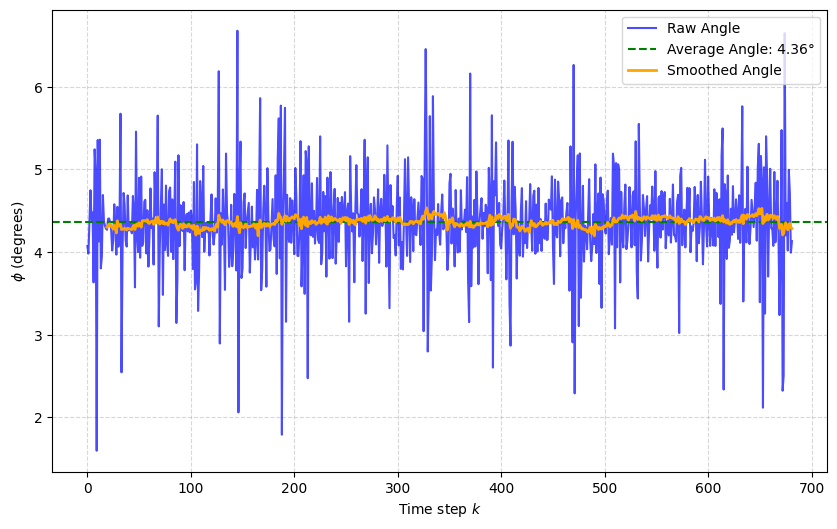

count    682.000000
mean       0.032138
std       96.841632
min     -416.438356
25%      -46.575342
50%        0.000000
75%       46.575342
max      405.479452
Name: delta_dot, dtype: float64 


Processing file:  Exp 2 fast data target 5 degrees
length(clean_states): 516
Plot saved as line_plot_Exp_2_fast_data_target_5_degrees_avg_5.99.pdf


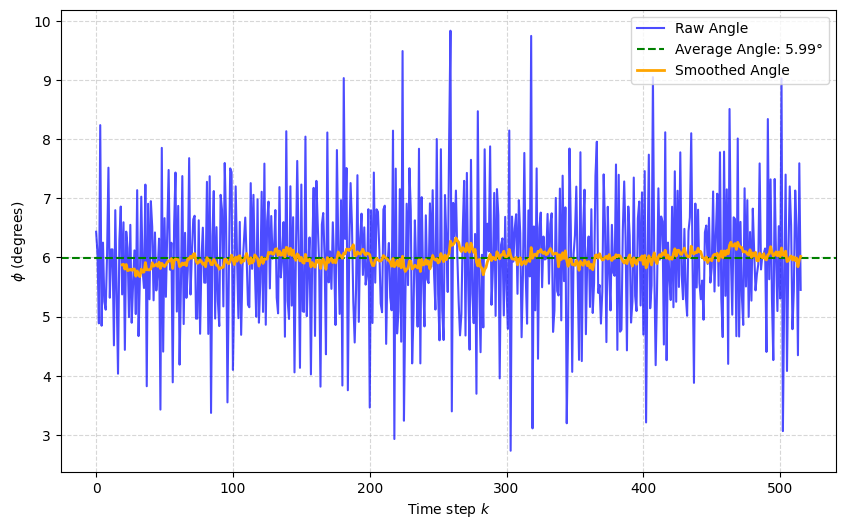

count    516.000000
mean       0.302644
std      184.837221
min     -501.369863
25%     -136.986301
50%       13.698630
75%      134.246575
max      558.904110
Name: delta_dot, dtype: float64 


Processing file:  Exp 3 fast data target 3.5 degrees Fixed screw
length(clean_states): 212
Plot saved as line_plot_Exp_3_fast_data_target_3.5_degrees_Fixed_screw_avg_5.21.pdf


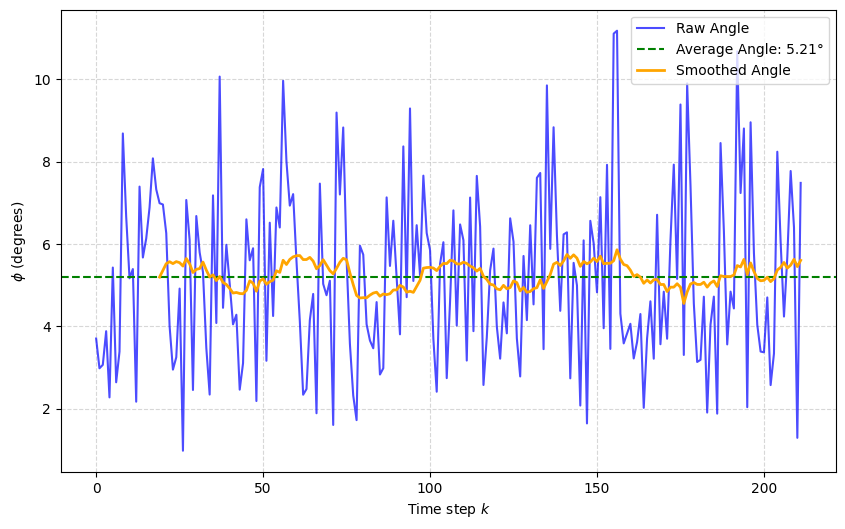

count    212.000000
mean       1.524942
std      371.313629
min     -728.767123
25%     -312.328767
50%        4.109589
75%      265.753425
max      712.328767
Name: delta_dot, dtype: float64 


Processing file:  Exp 4 fast data target 4.0 degrees Fixed screw
length(clean_states): 673
Plot saved as line_plot_Exp_4_fast_data_target_4.0_degrees_Fixed_screw_avg_4.24.pdf


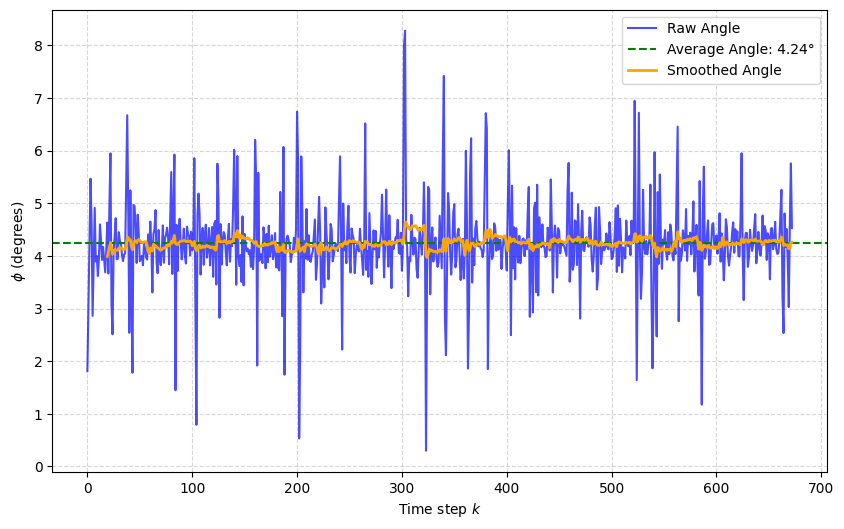

count    673.000000
mean       0.113986
std      112.694247
min     -468.493151
25%      -52.054795
50%        2.739726
75%       57.534247
max      400.000000
Name: delta_dot, dtype: float64 



In [44]:
# Specify file names
file_names = []
# file_names.append("data-limited2")
# file_names.append("Good_no_fallings_original_data:large_left_circle")
# file_names.append("bike_in_air_data")
# file_names.append("bike_pushed_data")
# file_names.append("bike_pushed_data2")
# file_names.append("medium_left_circle_with_float_data")
# file_names.append("medium_left_circle_with_float_data+noisy_input")
# file_names.append("Exp 1: LQR with fork")
# file_names.append("Exp 2: LQR without fork")
# file_names.append("Exp 4: DDFB without fork angle mean_angle=4.9")
# file_names.append("Exp 4: DDFB without fork angle target_angle=2.0")
# file_names.append("Exp 4: DDFB without fork angle target_angle=4.9")
# file_names.append("Exp 4: DDFB without fork angle mean_angle=2.0")
# file_names.append("Exp 2: DDFB with fork angle mean_angle=2.0") // not yet collected
# file_names.append("Final experiments/Exp 1 fast data target 4.0 degrees Fixed screw")
# file_names.append("Final experiments/Exp 2 fast data target 5 degrees")
# file_names.append("Final experiments/Exp 3 fast data target 3.5 degrees Fixed screw")
# file_names.append("Final experiments/Exp 4 fast data target 4.0 degrees Fixed screw")
file_names.append("Exp 1 fast data target 4.0 degrees Fixed screw")
file_names.append("Exp 2 fast data target 5 degrees")
file_names.append("Exp 3 fast data target 3.5 degrees Fixed screw")
file_names.append("Exp 4 fast data target 4.0 degrees Fixed screw")
# file_names.append("Final experiments/Static 0 degrees data")

data = ""
figures = []
costs = []
for file_name in file_names:
    print("\nProcessing file: ", file_name)
    # Read the content of the file
    with open(file_name, "r") as file:
        data = file.read()

    # Pattern to match ${A..} and ${B..} blocks
    # pattern = r"\{([AB]\d+\.\d+:[^}]+)\}\$"
    pattern = r"\{([AB]-?\d+\.\d+:[^}]+)\}\$"

    # Extract matches using regex
    matches = re.findall(pattern, data)

    # Process and categorize the matches
    data_blocks = {"A": [], "B": []}
    for match in matches:
        if match.startswith("A"):
            data_blocks["A"].append(match)
        elif match.startswith("B"):
            data_blocks["B"].append(match)



    # Parse data for A and B blocks
    parsed_data = {"A": [parse_entry(entry) for entry in data_blocks["A"]],
                "B": [parse_entry(entry) for entry in data_blocks["B"]]}
    # Optionally, save to a file
    with open("parsed_data.json", "w") as f:
        import json
        json.dump(parsed_data, f, indent=4)

    # Load the JSON file
    json_file = "parsed_data.json"  # Ensure this is the correct path to your JSON file

    with open(json_file, "r") as f:
        data = json.load(f)

    # Convert the "A" and "B" blocks to pandas DataFrames
    df_a = pd.DataFrame(data["A"], columns=["Encoder1", "Encoder2", "Voltage", "phi"], dtype=float)
    df_b = pd.DataFrame(data["B"], columns=["phi", "phi_dot", "Servo"], dtype=float)

    # Save as CSV for further analysis if needed
    df_a.to_csv("parsed_A_data.csv", index=False)
    df_b.to_csv("parsed_B_data.csv", index=False)


    MID = 750
    delta = (df_b['Servo'] - MID) / 3.65
    df_b['delta'] = delta

    # Filter out states with phi > 45 degrees
    # clean_states = df_b[df_b['phi'].abs() <= 30]
    clean_states = df_b
    print(f'length(clean_states): {len(clean_states)}')
    clean_states = clean_states.drop(columns=['Servo'])[['phi', 'phi_dot', 'delta']]
    # clean_states['phi'].mean()

    ## Compute delta dot for matlab_inputs_u_g
    Ts = 0.10
    clean_states['delta_dot'] = clean_states['delta'].diff()
    clean_states['delta_dot'] = clean_states['delta_dot'].fillna(0)
    clean_states['delta_dot'] = clean_states['delta_dot'].shift(-1)
    clean_states['delta_dot'] = clean_states['delta_dot'].fillna(0) / Ts

    figures.append(plot_line(clean_states['phi'], file_name, save_fig=True))
    # if file_name contains("static")
    if "Static" in file_name:
        continue
    costs.append(compute_closed_cost(clean_states))
    # Max angles for S_x
    # print(clean_states['phi'].describe(), '\n')
    # print(clean_states['phi_dot'].describe(), '\n')
    # print(clean_states['delta'].describe())

    print(clean_states['delta_dot'].describe(), '\n')

In [45]:
(640- MID) / 3.65
(900- MID) / 3.65

41.09589041095891

In [46]:
## Modelling of the errors as Gaussian Noise
mu = np.mean(clean_states['phi'])
sigma = np.std(clean_states['phi'])
print(f"Mean: {mu}, Standard Deviation: {sigma}")

Mean: 4.235891530460624, Standard Deviation: 0.7895019788222353


In [47]:
# delta.plot.hist(bins=100) #   -35 < delta < 36    -22.5 < delta < -5 [[when circling to the left]]
# (df_b['delta']).plot.hist(bins=100)
# df_b['phi_dot'].plot.hist(bins=50)
# df_b['phi_dot'].unique
# df_b['phi'].plot.hist(bins=50)
# df_b['delta']

In [48]:
print( (60-33.37+7.025) / 148 )
print((70) / 304)
print((60-3.052 + 22.204) / 324)

0.22739864864864864
0.23026315789473684
0.2442962962962963


In [49]:
# Current
(41.618-36.304)/23
(17.132-15.011)/10

# Original
(46.618-40.012)/35
(9.905+(60-58.142))/62

(2.167+(60-44.932))/83 #2.1f

(3.052+(60-53.168))/47 # .3f
(3.052+(60-53.168))/47 # .3f -no_if
(26.232-14.958)/86 #or84

0.13109302325581396

In [50]:
# Max angles for S_x
print(clean_states['phi'].describe(), '\n')
print(clean_states['phi_dot'].describe(), '\n')
print(clean_states['delta'].describe())

count    673.000000
mean       4.235892
std        0.790089
min        0.299000
25%        3.929000
50%        4.187000
75%        4.527000
max        8.277000
Name: phi, dtype: float64 

count    673.000000
mean       0.848851
std       11.290089
min      -52.012000
25%       -3.780000
50%        1.280000
75%        5.793000
max       47.378000
Name: phi_dot, dtype: float64 

count    673.000000
mean       6.765861
std        7.577299
min      -21.095890
25%        2.739726
50%        6.575342
75%       10.136986
max       36.986301
Name: delta, dtype: float64


In [59]:
1/((40/180*np.pi)**2 )
# np.sqrt(1/2.05)*180/np.pi
# 1/((45)**2)
# np.sqrt(1/5.9e-5)
1/((100/180*np.pi)**2 )
# np.sqrt(1/0.32828)*180/np.pi
1/((45/180*np.pi)**2 )
np.sqrt(1/1.62)*180/np.pi

# For phi, phi_dot, delta
# phi_max = 15  * np.pi / 180 # absolute
phi_max = 35  * np.pi / 180 # absolute
phi_dot_max = 100  * np.pi / 180 # absolute
delta_max = 40  * np.pi / 180 # absolute (-30 -> 40 degrees)
delta_dot_max = 750  * np.pi / 180 # absolute
print("S_x1 = ", 1 / (phi_max)**2)
print("S_x2 = ", 1 / (phi_dot_max)**2)
print("S_x3 = ", 1 / (delta_max)**2)
print("S_u = ", 1 / (delta_dot_max)**2)

S_x1 =  2.679841918376934
S_x2 =  0.3282806350011744
S_x3 =  2.0517539687573403
S_u =  0.005836100177798657


In [52]:
# Max angles for S_u
Ts = 0.1
clean_states['delta_dot'] = clean_states['delta'].diff()
clean_states['delta_dot'] = clean_states['delta_dot'].fillna(0)
clean_states['delta_dot'] = clean_states['delta_dot'].shift(-1)
clean_states['delta_dot'] = clean_states['delta_dot'].fillna(0) / Ts
print(clean_states['delta_dot'].describe(), '\n')

count    673.000000
mean       0.113986
std      112.694247
min     -468.493151
25%      -52.054795
50%        2.739726
75%       57.534247
max      400.000000
Name: delta_dot, dtype: float64 



In [53]:
1/((200/180*np.pi)**2)
# np.sqrt(1/0.08207)*180/np.pi

0.0820701587502936

In [54]:
# plot_line(clean_states['delta'], file_name + " delta", save_fig=True)

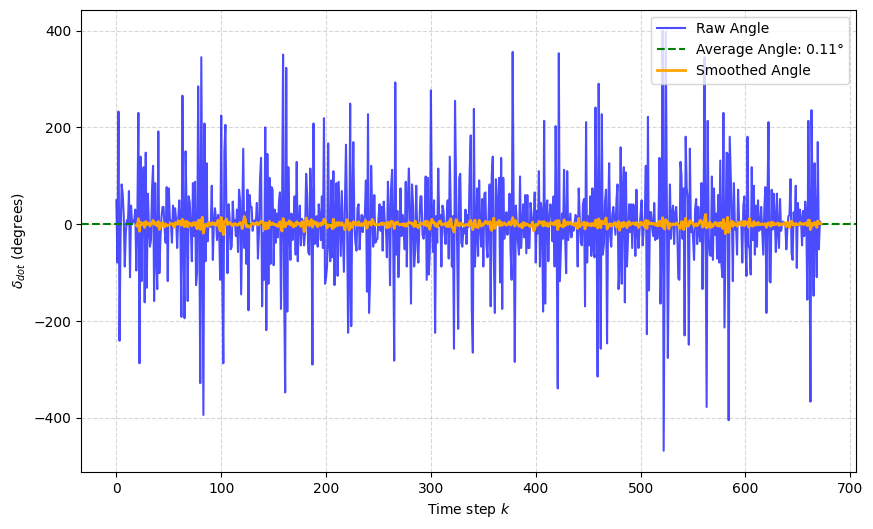

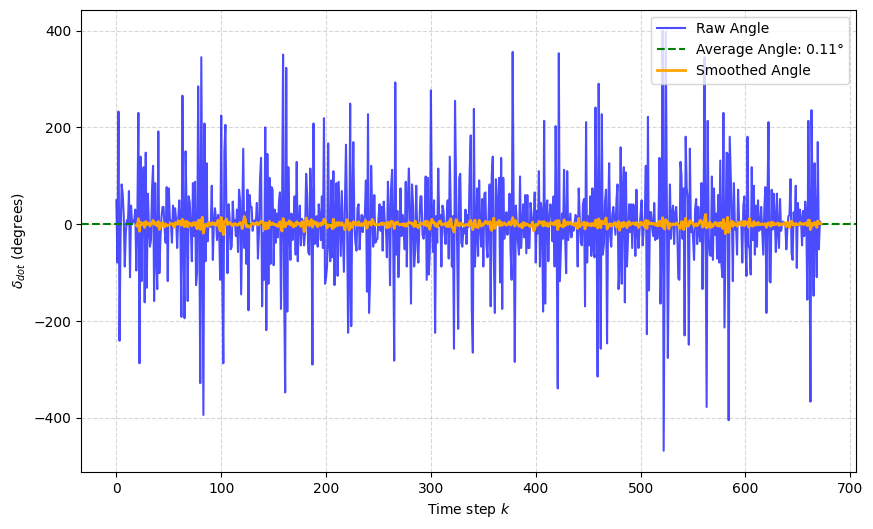

In [55]:
plot_line(clean_states['delta_dot'], file_name + " delta_dot", save_fig=False)